# 04 · Talladures de Dedekind

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/04_Talladures_Dedekind.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Descriure un nombre a partir de l'ordre dels racionals i entendre una construcció de ℝ.

**Abans de començar:** quadern 01 i ordre de les fraccions  
**Temps orientatiu:** 1–2 sessions. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Quadern nou. Context: Dedekind, Continuïtat i nombres irracionals (1872).


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Podem situar un nombre sense disposar d'una fracció que l'expressi?

**Al final ho has de poder explicar:** Entendre una talladura com una regla de classificació abans de llegir-ne la definició formal.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. Un nombre pot separar la recta
La talladura determinada per $3/2$ separa els racionals en
$A=\{q\in\mathbb Q:q<3/2\}$ i $B=\{q\in\mathbb Q:q\ge3/2\}$.
En aquesta convenció, la part inferior **no té màxim**. La part superior sí que té
mínim: $3/2$. Dibuixa alguns elements de cada part abans d'executar.

Per construir la talladura que representarà $\sqrt2$, no l'hem d'usar com a entrada:
$$A=\{q\in\mathbb Q:q<0\ \text{o}\ q^2<2\},\qquad B=\mathbb Q\setminus A.$$


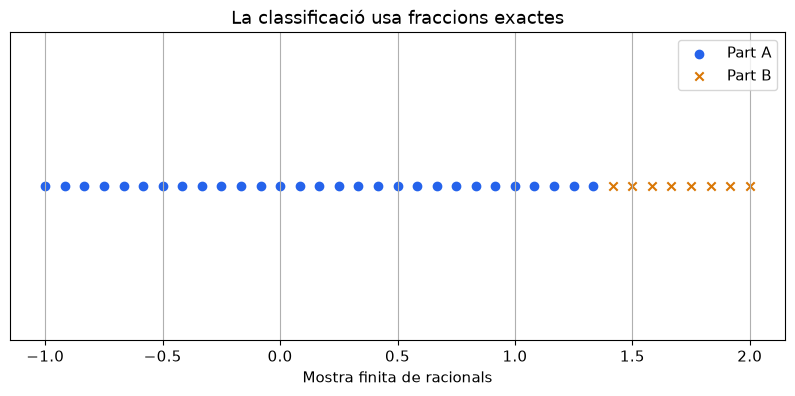

Màxim d'A dins de la mostra: 4/3
Això NO és un màxim del conjunt infinit A.


interactive(children=(IntSlider(value=12, description='denominador', max=40, min=2), Dropdown(description='tal…

In [2]:
def pertany_inferior(q, tall="arrel2"):
    q = Fraction(q)
    if tall == "racional":
        return q < Fraction(3, 2)
    if tall == "arrel2":
        return q < 0 or q*q < 2
    raise ValueError("Tall desconegut.")

def dibuixa_tall(denominador=12, tall="arrel2"):
    punts = [Fraction(i, denominador) for i in range(-denominador, 2*denominador+1)]
    a = [q for q in punts if pertany_inferior(q, tall)]
    b = [q for q in punts if not pertany_inferior(q, tall)]
    fig, ax = plt.subplots()
    ax.scatter([float(q) for q in a], np.zeros(len(a)), color="#2563eb", label="Part A")
    ax.scatter([float(q) for q in b], np.zeros(len(b)), color="#d97706", marker="x", label="Part B")
    ax.set(yticks=[], xlabel="Mostra finita de racionals", title="La classificació usa fraccions exactes")
    ax.legend(); plt.show()
    print("Màxim d'A dins de la mostra:", max(a))
    print("Això NO és un màxim del conjunt infinit A.")
panell = explora(dibuixa_tall, denominador=(2, 40, 1), tall=["racional", "arrel2"])


## Laboratori animat · observa, atura i explica


### Un detector: aquest racional queda abans o després de √2?

No necessitem els decimals de √2 per classificar un racional $q$:

- Si $q<0$, queda a l'esquerra perquè √2 és positiu.
- Si $q\ge0$, comparem **exactament** $q^2$ amb 2.
- Si $q^2<2$, posem $q$ al grup A; si $q^2>2$, al grup B.

Per exemple, $(7/5)^2=49/25<2$ i $(10/7)^2=100/49>2$.
El primer és inferior i el segon superior. Cap racional té quadrat 2.
La regla és aplicable a tots els racionals, encara que el gràfic només en mostri uns quants.

**Prediu** la classificació de $-3/2$, $1$, $3/2$ i $7/5$.
**Durant l'animació**, llegeix la fracció i la comparació abans de mirar el color.
La corba dreta mostra per què comparar quadrats funciona per als candidats positius.


In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [4]:
titol_laboratori = "Separar els racionals amb una regla exacta"
candidats_tall = [Fraction(1), Fraction(3, 2), Fraction(7, 5), Fraction(10, 7),
                  Fraction(41, 29), Fraction(99, 70), Fraction(1414, 1000), Fraction(1415, 1000),
                  Fraction(14142, 10000), Fraction(14143, 10000)]
fotogrames_laboratori = list(range(len(candidats_tall)))

def dibuixa_laboratori(pas, axes):
    ax, bx = axes
    q = candidats_tall[pas]
    inferior = q*q < 2
    color = "#2563eb" if inferior else "#ea580c"
    ax.axhline(0, color="0.6")
    for k, r in enumerate(candidats_tall[:pas+1]):
        ax.scatter(float(r), .06*(k%3), color="#2563eb" if r*r < 2 else "#ea580c", s=45)
    ax.scatter(float(q), -.13, s=90, marker="^", color=color)
    ax.set(xlim=(.96, 1.54), ylim=(-.3, .3), yticks=[], xlabel="Posició del racional",
           title=f"q = {q} ≈ {float(q):.7f}\nGrup {'A: inferior' if inferior else 'B: superior'}")
    x = np.linspace(.95, 1.55, 300)
    bx.plot(x, x*x, color="#7c3aed", label="y = x²")
    bx.axhline(2, color="0.4", ls="--", label="y = 2")
    bx.scatter(float(q), float(q*q), color=color, s=70, zorder=5)
    bx.plot([float(q), float(q)], [0, float(q*q)], ":", color=color)
    bx.set(xlim=(.95, 1.55), ylim=(.85, 2.45), xlabel="q ≥ 0", ylabel="Quadrat de q",
           title=f"q² = {q*q}\nComparació exacta: q² {'<' if inferior else '>'} 2")
    bx.legend(fontsize=8)


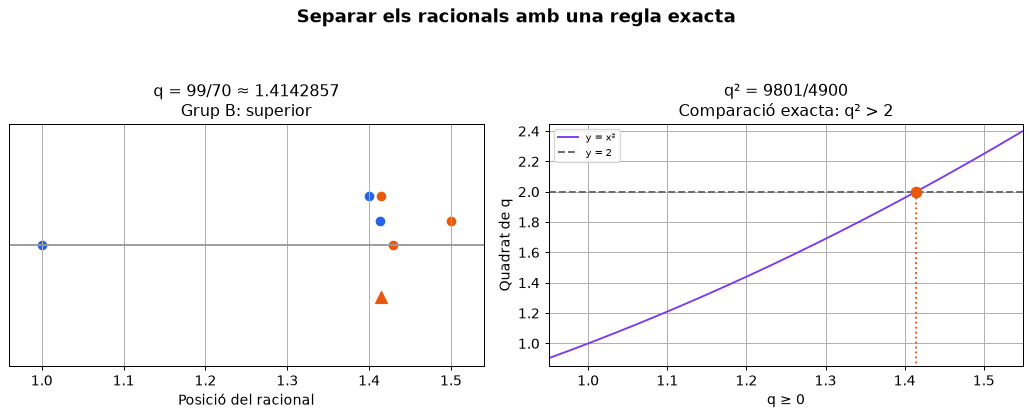

In [5]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(fotogrames_laboratori[len(fotogrames_laboratori)//2])


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [6]:
display(anima_laboratori())


### Compara abans de concloure

Compara 7/5 amb 10/7. Escriu els quadrats com a fraccions exactes i explica per què queden en grups diferents. El decimal del títol serveix per situar-los, però no per decidir la classificació.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [7]:
parella_comparacio = (2, 3)
etiquetes_comparacio = [f"q = {candidats_tall[k]}" for k in fotogrames_laboratori]
preguntes_taller = [{'enunciat': 'On queda −2 respecte de √2?', 'opcions': ['A la dreta, perquè el seu quadrat és 4', "A l'esquerra, perquè és negatiu", 'No es pot saber'], 'correcta': 1, 'retorn': ["Elevar al quadrat no conserva l'ordre si comparem negatius amb positius.", 'Correcte: √2 és positiu i qualsevol nombre negatiu és inferior.', 'No calen decimals: el signe ja permet decidir.']}, {'enunciat': 'En la talladura A={q racional: q<3/2}, el nombre 3/2...', 'opcions': ['És el mínim de B', "És el màxim d'A", 'No pertany a cap grup'], 'correcta': 0, 'retorn': ['Correcte: A exclou la frontera i B la inclou.', 'La desigualtat que defineix A és estricta: 3/2 no pertany a A.', 'Els dos grups han de classificar tots els racionals.']}, {'enunciat': 'Mostrar deu fraccions a cada costat descriu tota la talladura?', 'opcions': ['Sí, si són molt properes', 'Sí, perquè el gràfic és continu', 'No: la defineix una regla per a tots els racionals'], 'correcta': 2, 'retorn': ['La proximitat no converteix una llista finita en el conjunt complet.', 'La línia del dibuix no és una enumeració de tots els racionals.', 'Correcte: el dibuix il·lustra la regla, però només en mostra una part finita.']}]


In [8]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


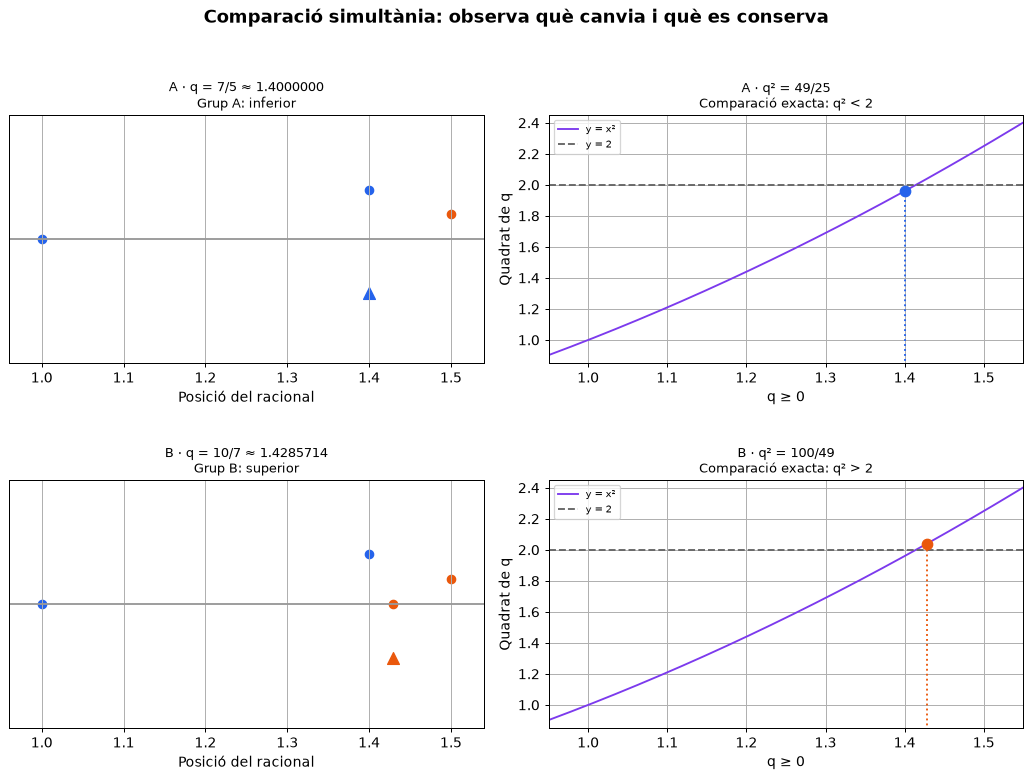

interactive(children=(Dropdown(description='Estat A:', index=2, options=(('q = 1', 0), ('q = 3/2', 1), ('q = 7…

In [9]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Construeix ara una regla per a la frontera √3. Conserva el tractament separat dels negatius. Afegeix dues fraccions noves, una a cada costat, i justifica la decisió amb el quadrat.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


In [10]:
nombre_sota_arrel = Fraction(3)
candidats = [Fraction(-2), Fraction(5, 3), Fraction(7, 4), Fraction(2)]
for q in candidats:
    if q < 0 or q*q < nombre_sota_arrel:
        grup = "A: inferior"
    elif q*q == nombre_sota_arrel:
        grup = "B: igual a la frontera (quan és racional)"
    else:
        grup = "B: superior"
    print(f"q={q}; q²={q*q}; {grup}")


q=-2; q²=4; A: inferior
q=5/3; q²=25/9; A: inferior
q=7/4; q²=49/16; B: superior
q=2; q²=4; B: superior


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. On queda −2 respecte de √2?**

- A. A la dreta, perquè el seu quadrat és 4
- B. A l'esquerra, perquè és negatiu
- C. No es pot saber

**2. En la talladura A={q racional: q<3/2}, el nombre 3/2...**

- A. És el mínim de B
- B. És el màxim d'A
- C. No pertany a cap grup

**3. Mostrar deu fraccions a cada costat descriu tota la talladura?**

- A. Sí, si són molt properes
- B. Sí, perquè el gràfic és continu
- C. No: la defineix una regla per a tots els racionals

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [11]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Classifica $-2$, $0$, $4/3$ i $17/12$ sense usar `sqrt` ni una aproximació de √2.
2. Per què no podem aplicar «$q^2<2$» com a única regla quan $q$ és negatiu?
3. En la talladura que representa 3/2, a quin grup pertany 3/2 si A conté els racionals
   estrictament menors? Té A un màxim? Té B un mínim?
4. Escriu amb paraules què aporta una talladura: un decimal aproximat o una regla que
   determina una frontera? Distingeix la regla completa de la mostra del dibuix.


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [12]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

−2, 0 i 4/3 són a A; 17/12 és a B perquè $289/144>2$.
−2 és inferior a √2 tot i tenir quadrat 4. Per a la frontera racional 3/2,
aquest nombre és a B: B té mínim i A no té màxim. La talladura defineix la frontera
a través de tots els racionals; la gràfica només en mostra una part finita.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 2. Propietats que cal justificar · Ampliació formal
Una talladura és una partició $\mathbb Q=A\cup B$, amb $A\cap B=\varnothing$,
totes dues parts no buides, tot element d'A menor que qualsevol de B, i A sense màxim.

En el cas de l'arrel de 2: $1\in A$, $2\in B$, i la monotonia del quadrat sobre
els nombres no negatius justifica l'ordre. Falta demostrar que A no té màxim.
El programa següent construeix un racional més gran dins d'A per a cada $q\in A$.


In [13]:
def mes_gran_dins_A(q):
    q = Fraction(q)
    if not pertany_inferior(q):
        raise ValueError("Cal començar amb q dins d'A.")
    if q < 0:
        return Fraction(0)
    h = (2-q*q) / (2*(2*q+1))
    return q+h

for q in [Fraction(-3), Fraction(0), Fraction(7,5), Fraction(1414,1000)]:
    r = mes_gran_dins_A(q)
    print(f"q={q}; r={r}; q<r i r∈A: {q < r and pertany_inferior(r)}")


q=-3; r=0; q<r i r∈A: True
q=0; r=1; q<r i r∈A: True
q=7/5; r=267/190; q<r i r∈A: True
q=707/500; r=2706547/1914000; q<r i r∈A: True


**Demostració.** Si $0\le q$ i $q^2<2$, prenem
$h=(2-q^2)/(2(2q+1))$. Tenim $0<h\le1$ i
$$2qh+h^2\le(2q+1)h=(2-q^2)/2<2-q^2.$$
Per tant $(q+h)^2<2$ i $q+h\in A$. Si $q<0$, el racional 0 ja és més gran i és dins d'A.

## 3. Què estem construint? · Ampliació formal
Una talladura racional representa un racional ja conegut. La talladura anterior
representa un punt que no correspon a cap racional: ni A té màxim ni B té mínim.
La construcció de Dedekind pren les talladures com a nombres reals i hi defineix
l'ordre i les operacions. Aquí n'estudiem la idea; no desenvolupem tota la construcció del cos.

**Ampliació: per què B no té mínim?** Per a $q\in B$ tenim $q>0$ i $q^2>2$.
Prenent $h=(q^2-2)/(2q)$, el racional $r=q-h$ satisfà $0<r<q$ i
$r^2=2+h^2>2$. Per tant $r\in B$.

## Activitats
1. Classifica $-2$, $7/5$, $10/7$ i $3/2$ sense decimals.
2. Explica per què no podem definir A només amb $q^2<2$: què passaria amb $-3$?
3. Canvia 2 per 9. Quina part de la talladura té un extrem racional?
4. Relaciona les dues parts amb els extrems dels intervals de bisecció del quadern 01.

<details><summary>Comprovació</summary>

$-2$ i $7/5$ són a A; $10/7$ i $3/2$ són a B. El nombre $-3$ ha d'estar
a l'esquerra de la frontera, encara que el seu quadrat sigui més gran que 2.
Per a l'arrel de 9, B té mínim 3. A continua sense màxim.
</details>

**Lectura:** [Dedekind, Continuidad y números irracionales](https://www.uv.es/jkliment/Documentos/Dedekind.pc.pdf).
La lectura és complementària; el quadern s'executa sense connexió a aquest document.


**Navegació:** [Anterior](NumeroPi.ipynb) · [Índex i guia](README.md) · [Següent](05_Successions_Cauchy.ipynb)
